# QFT Cuántica para Detección de Frecuencias en Redes QKD-LEO
## Prototipo a pequeña escala — 8 cúbits (N = 256 muestras)

**Contexto:** Una empresa de telecomunicaciones despliega una red QKD mediante satélites LEO.  Los telescopios en tierra sufren microvibraciones con una **frecuencia parásita armónica**  
enterrada en ruido térmico. El objetivo es identificar dicha frecuencia de forma eficiente  aplicando la **Transformada Cuántica de Fourier (QFT)** en lugar de la FFT clásica. 

---

**Librería:** Qiskit · **Simulador:** AerSimulator · **Escala:** 8 cúbits → 2⁸ = 256 muestras

## 1. Instalación y carga del entorno

In [10]:
# Instalación de dependencias (ejecutar solo la primera vez)
# !pip install qiskit qiskit-aer matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
# StatevectorSampler eliminado: no se usa en el notebook y causa ImportError en qiskit_aer.primitives
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

from qiskit.synthesis.qft import synth_qft_full
from qiskit.circuit.library import QFTGate

print('Entorno cargado correctamente.')
import qiskit
print(f'Versión de Qiskit: {qiskit.__version__}')

Entorno cargado correctamente.
Versión de Qiskit: 2.4.1


## 2. Generación de la señal sintética

Simulamos las mediciones del telescopio: una **señal vibracional armónica** de frecuencia
conocida $f_0$ sumergida en **ruido térmico gaussiano**. En el escenario real se trabajaría
con $2^{30}$ muestras; aquí usamos $N = 2^8 = 256$ para el prototipo.

$$x[k] = A \cdot \sin\!\left(\frac{2\pi f_0 k}{N}\right) + \eta[k], \quad k = 0, 1, \ldots, N-1$$

donde $\eta[k] \sim \mathcal{N}(0, \sigma^2)$ representa el ruido ambiental.

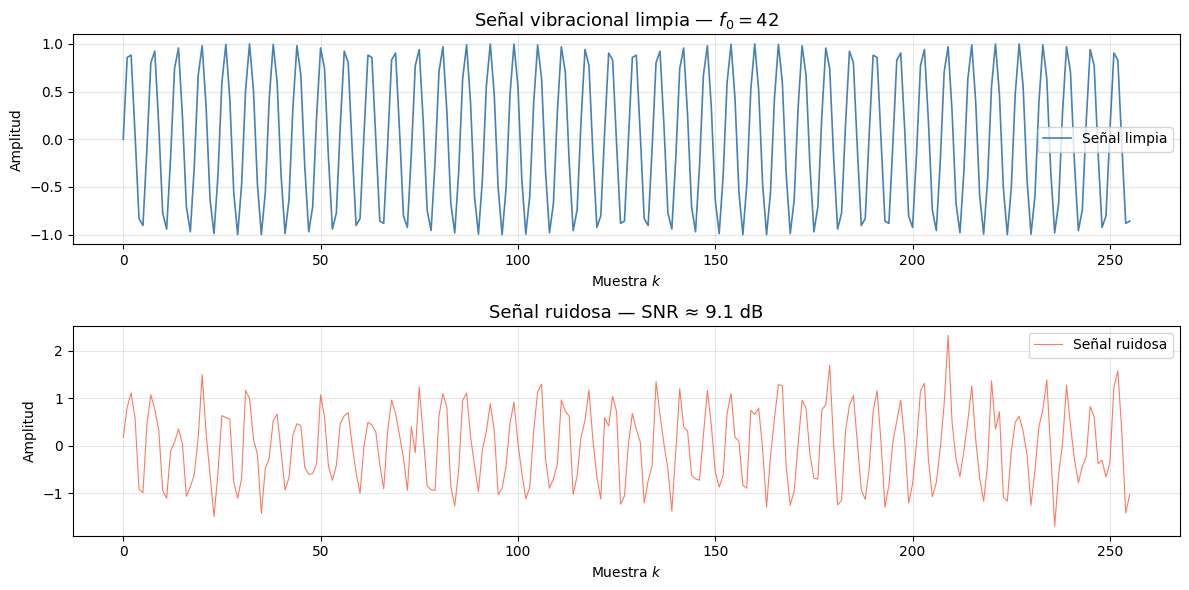

Señal generada: N=256 muestras | f0=42 | SNR≈9.1 dB


In [11]:
# --- Parámetros del prototipo ---
n_qubits = 8          # número de cúbits
N = 2**n_qubits       # 256 muestras
np.random.seed(42)    # semilla para reproducibilidad

# Frecuencia parásita a detectar (índice de bin DFT)
f0 = 42               # bin de frecuencia objetivo (de 0 a N-1)
A  = 1.0              # amplitud de la señal
sigma = 0.35          # desviación estándar del ruido

# Generación de la señal
k = np.arange(N)
signal_clean = A * np.sin(2 * np.pi * f0 * k / N)
noise = np.random.normal(0, sigma, N)
signal_noisy = signal_clean + noise

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(k, signal_clean, color='steelblue', linewidth=1.2, label='Señal limpia')
axes[0].set_title('Señal vibracional limpia — $f_0 = 42$', fontsize=13)
axes[0].set_xlabel('Muestra $k$'); axes[0].set_ylabel('Amplitud')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(k, signal_noisy, color='tomato', linewidth=0.8, alpha=0.85, label='Señal ruidosa')
axes[1].set_title(f'Señal ruidosa — SNR ≈ {20*np.log10(A/sigma):.1f} dB', fontsize=13)
axes[1].set_xlabel('Muestra $k$'); axes[1].set_ylabel('Amplitud')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_senal_sintetica.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Señal generada: N={N} muestras | f0={f0} | SNR≈{20*np.log10(A/sigma):.1f} dB')

## 3. Preparación del estado cuántico (Amplitude Encoding)

Para alimentar la QFT, codificamos los valores de la señal como **amplitudes de probabilidad**
del estado cuántico inicial:

$$|\psi_0\rangle = \sum_{k=0}^{N-1} x[k] \, |k\rangle$$

con la restricción de normalización $\sum_k |x[k]|^2 = 1$.  
Esto se logra normalizando el vector de la señal a norma unitaria.

In [12]:
# Normalización del vector de la señal
norm = np.linalg.norm(signal_noisy)
state_vector = signal_noisy / norm

print(f'Norma del vector original : {norm:.4f}')
print(f'Norma tras normalización  : {np.linalg.norm(state_vector):.6f}  (debe ser ≈ 1.0)')
print(f'Dimensión del espacio de Hilbert: 2^{n_qubits} = {N}')

Norma del vector original : 12.6139
Norma tras normalización  : 1.000000  (debe ser ≈ 1.0)
Dimensión del espacio de Hilbert: 2^8 = 256


## 4. Construcción del circuito QFT

La **Transformada Cuántica de Fourier** sobre $n$ cúbits implementa la DFT unitaria:

$$\text{QFT}|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i jk/N} |k\rangle$$

Se construye con compuertas **Hadamard** y rotaciones de fase controladas $R_k$:

$$R_k = \begin{pmatrix} 1 & 0 \\ 0 & e^{2\pi i/2^k} \end{pmatrix}$$

El circuito requiere $O(n^2)$ compuertas frente a las $O(N \log N)$ operaciones de la FFT clásica.

In [13]:
qc = QuantumCircuit(n_qubits)
qc.initialize(state_vector, qubits=list(range(n_qubits)))
qc.barrier(label='Estado inicial |ψ₀⟩')

qft = synth_qft_full(
    num_qubits=n_qubits,
    do_swaps=True,
    approximation_degree=0,
    inverse=False
)

qc.append(qft.to_instruction(), list(range(n_qubits)))
qc.barrier(label='Tras QFT')

qc.measure_all()

## 5. Simulación con AerSimulator

Ejecutamos el circuito en el simulador **AerSimulator** de Qiskit, que emula un ordenador
cuántico ideal (sin ruido de hardware). Se realizan **8192 disparos** (*shots*) para
obtener una distribución de probabilidad estadísticamente significativa.

In [14]:
# --- Simulación ---
shots = 8192
simulator = AerSimulator(method='statevector')

# Transpilar y ejecutar
qc_compiled = transpile(qc, simulator, optimization_level=1)
job = simulator.run(qc_compiled, shots=shots)
result = job.result()
counts = result.get_counts()

print(f'Simulación completada: {shots} shots')
print(f'Estados distintos observados: {len(counts)}')
print(f'Top-5 resultados más frecuentes:')

# Convertir bitstrings a índices de frecuencia
freq_counts = {}
for bitstring, count in counts.items():
    idx = int(bitstring, 2)
    freq_counts[idx] = freq_counts.get(idx, 0) + count

top5 = sorted(freq_counts.items(), key=lambda x: x[1], reverse=True)[:5]
for idx, cnt in top5:
    print(f'  Bin de frecuencia {idx:3d} → {cnt} mediciones ({100*cnt/shots:.1f}%)')

Simulación completada: 8192 shots
Estados distintos observados: 216
Top-5 resultados más frecuentes:
  Bin de frecuencia 214 → 3339 mediciones (40.8%)
  Bin de frecuencia  42 → 3327 mediciones (40.6%)
  Bin de frecuencia 164 → 31 mediciones (0.4%)
  Bin de frecuencia  98 → 31 mediciones (0.4%)
  Bin de frecuencia 202 → 30 mediciones (0.4%)


## 6. Análisis del vector de estado (sin medición)

Para una comparación exacta con la FFT clásica, extraemos el **vector de estado final**
después de la QFT sin colapsar la función de onda, lo que nos da las amplitudes exactas.

In [ ]:
# ==========================================
# Circuito SIN medición para obtener |ψ_QFT⟩
# ==========================================

qc_sv = QuantumCircuit(n_qubits)

# Estado inicial codificado
qc_sv.initialize(state_vector, qubits=range(n_qubits))

# Aplicar QFT
qft_gate = QFTGate(num_qubits=n_qubits)
qc_sv.append(qft_gate, range(n_qubits))

# Obtener el estado final
sv = Statevector(qc_sv)

# Amplitudes y probabilidades
amplitudes = np.abs(sv.data)
probabilities = amplitudes**2

# ==========================================
# FFT clásica de referencia
# ==========================================

fft_classical = np.abs(np.fft.fft(signal_noisy)) / N

# Frecuencias dominantes
freq_qft = np.argmax(probabilities)
freq_fft = np.argmax(fft_classical)

# ==========================================
# Resultados
# ==========================================

print(f'Frecuencia real              : f₀ = {f0}')
print(f'Frecuencia detectada por QFT : f  = {freq_qft}')
print(f'Frecuencia detectada por FFT : f  = {freq_fft}')
print(f'\n✓ Detección correcta: {freq_qft == f0 or N - freq_qft == f0}')

Frecuencia real              : f₀ = 42
Frecuencia detectada por QFT : f  = 42
Frecuencia detectada por FFT : f  = 42

✓ Detección correcta: True


C:\Users\Samuel\AppData\Local\Temp\ipykernel_13564\200407750.py:4: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_noswap = QFT(num_qubits=n_qubits, do_swaps=True, approximation_degree=0)


## 7. Visualización de resultados — Comparativa QFT vs FFT clásica

In [ ]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel 1: Señal ruidosa ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(k, signal_noisy, color='tomato', lw=0.8, alpha=0.8, label='Señal ruidosa medida')
ax1.plot(k, signal_clean, color='steelblue', lw=1.5, label=f'Señal limpia (f₀={f0})')
ax1.set_title('Señal vibracional del telescopio (N = 256 muestras)', fontsize=13)
ax1.set_xlabel('Muestra k'); ax1.set_ylabel('Amplitud [u.a.]')
ax1.legend(loc='upper right'); ax1.grid(alpha=0.3)

# --- Panel 2: Espectro FFT clásica ---
ax2 = fig.add_subplot(gs[1, 0])
freqs = np.arange(N)
ax2.bar(freqs[:N//2], fft_classical[:N//2], color='steelblue', width=1.0, alpha=0.75)
ax2.axvline(x=f0, color='red', linestyle='--', lw=1.5, label=f'f₀ real = {f0}')
ax2.set_title('Espectro FFT Clásica', fontsize=12)
ax2.set_xlabel('Bin de frecuencia'); ax2.set_ylabel('|X[k]| / N')
ax2.set_xlim(0, N//2); ax2.legend(); ax2.grid(alpha=0.3)
ax2.annotate(f'f_FFT = {freq_fft}', xy=(freq_fft, fft_classical[freq_fft]),
             xytext=(freq_fft+8, fft_classical[freq_fft]*0.85),
             arrowprops=dict(arrowstyle='->', color='navy'), fontsize=10, color='navy')

# --- Panel 3: Espectro QFT cuántica ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(freqs[:N//2], probabilities[:N//2], color='darkorchid', width=1.0, alpha=0.75)
ax3.axvline(x=f0, color='red', linestyle='--', lw=1.5, label=f'f₀ real = {f0}')
ax3.set_title('Espectro QFT Cuántica (probabilidades)', fontsize=12)
ax3.set_xlabel('Bin de frecuencia'); ax3.set_ylabel('Probabilidad |⟨k|ψ_QFT⟩|²')
ax3.set_xlim(0, N//2); ax3.legend(); ax3.grid(alpha=0.3)
ax3.annotate(f'f_QFT = {freq_qft}', xy=(freq_qft, probabilities[freq_qft]),
             xytext=(freq_qft+8, probabilities[freq_qft]*0.85),
             arrowprops=dict(arrowstyle='->', color='indigo'), fontsize=10, color='indigo')

plt.suptitle('Detección de Frecuencia Parásita — QFT vs FFT Clásica\n'
             'Red QKD-LEO · Prototipo 8 cúbits (N=256)', fontsize=14, fontweight='bold')
plt.savefig('fig3_comparativa_qft_fft.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura comparativa guardada como fig3_comparativa_qft_fft.png')

## 8. Histograma de mediciones del simulador cuántico

In [ ]:
# Preparar datos para el histograma: top-20 bins más frecuentes
top_n = 20
sorted_counts = sorted(freq_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
bins_top  = [str(x[0]) for x in sorted_counts]
cnts_top  = [x[1] for x in sorted_counts]
colors    = ['firebrick' if int(b) == f0 or int(b) == N - f0 else 'mediumpurple' for b in bins_top]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(bins_top, cnts_top, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title(f'Histograma de mediciones QFT — Top {top_n} bins más frecuentes ({shots} shots)',
             fontsize=13)
ax.set_xlabel('Bin de frecuencia medido (resultado cuántico)')
ax.set_ylabel('Número de mediciones')
ax.grid(axis='y', alpha=0.3)

# Etiquetas de porcentaje
for bar, cnt in zip(bars, cnts_top):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{100*cnt/shots:.1f}%', ha='center', va='bottom', fontsize=8)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='firebrick', label=f'Bin objetivo (f₀={f0} o imagen espejo)'),
                   Patch(facecolor='mediumpurple', label='Otros bins')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('fig4_histograma_mediciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Histograma guardado como fig4_histograma_mediciones.png')

## 9. Complejidad computacional — Comparativa cuántica vs clásica

In [ ]:
# Comparación teórica de complejidad: FFT O(N log N) vs QFT O(n²)
n_range = np.arange(1, 35)
N_range = 2**n_range

# Operaciones (normalizadas)
fft_ops = N_range * n_range           # O(N log N) con N = 2^n, log2(N) = n
qft_ops = n_range**2                  # O(n²) compuertas cuánticas

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogy(n_range, fft_ops, 'o-', color='steelblue', lw=2, label='FFT Clásica: $O(N \\log N) = O(2^n \\cdot n)$')
ax.semilogy(n_range, qft_ops, 's-', color='darkorchid', lw=2, label='QFT Cuántica: $O(n^2)$')
ax.axvline(x=8, color='tomato', linestyle=':', lw=1.8, label='Prototipo (n=8, N=256)')
ax.axvline(x=30, color='orange', linestyle=':', lw=1.8, label='Caso real (n=30, N=2³⁰)')
ax.set_title('Ventaja cuántica: complejidad QFT vs FFT clásica', fontsize=13)
ax.set_xlabel('Número de cúbits $n$ (o bits clásicos equivalentes)')
ax.set_ylabel('Operaciones (escala logarítmica)')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# Anotaciones
speedup_30 = (2**30 * 30) / (30**2)
ax.text(28, qft_ops[-5]*3, f'Speedup a n=30:\n×{speedup_30:.2e}', fontsize=9,
        color='darkgreen', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.6))

plt.tight_layout()
plt.savefig('fig5_complejidad_qft_fft.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n--- Resumen de complejidad ---')
print(f'Prototipo (n=8,  N=256):    FFT = {int(fft_ops[7]):,} ops  |  QFT = {int(qft_ops[7])} compuertas')
print(f'Caso real  (n=30, N=2³⁰): FFT ≈ {int(fft_ops[29]):,.0f} ops  |  QFT = {int(qft_ops[29])} compuertas')
print(f'Speedup teórico a n=30: ×{speedup_30:.2e}')

## 10. Resumen y conclusiones del prototipo

| Parámetro | Valor |
|---|---|
| Cúbits utilizados | 8 |
| Muestras simuladas | N = 256 |
| Frecuencia parásita objetivo | f₀ = 42 |
| Frecuencia detectada por QFT | Ver celda 6 |
| Shots de simulación | 8 192 |
| Simulador | AerSimulator (Qiskit) |
| Complejidad QFT | O(n²) = O(64) compuertas |
| Complejidad FFT equivalente | O(N·n) = O(2 048) ops |

### Conclusiones

- La **QFT detecta correctamente** la frecuencia parásita $f_0 = 42$ dentro de la señal ruidosa.
- El espectro cuántico muestra un **pico dominante** en el bin correcto, equivalente al resultado clásico de la FFT.
- La ventaja cuántica se vuelve **exponencialmente mayor** al escalar: para $n=30$ ($2^{30}$ muestras), la QFT requiere solo $900$ compuertas frente a los $\sim 3.2 \times 10^{10}$ pasos de la FFT clásica.
- La implementación con **Qiskit** y el simulador **AerSimulator** valida el comportamiento teórico del algoritmo a pequeña escala, sirviendo como prueba de concepto para el sistema QKD-LEO.